In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import NamedTuple

Read in the results from THINGS inference.

In [3]:
things_fold1 = pd.read_csv("../preds/inference/things_20260313_151142/things_summary.csv")
things_fold2 = pd.read_csv("../preds/inference/things_20260313_115616/things_summary.csv")
things_fold3 = pd.read_csv("../preds/inference/things_20260313_152710/things_summary.csv")
things_fold4 = pd.read_csv("../preds/inference/things_20260313_154651/things_summary.csv")
things_fold5 = pd.read_csv("../preds/inference/things_20260313_150223/things_summary.csv")

In [4]:
things_fold1_srcc = things_fold1['spearman_rho']
things_fold2_srcc = things_fold2['spearman_rho']
things_fold3_srcc = things_fold3['spearman_rho']
things_fold4_srcc = things_fold4['spearman_rho']
things_fold5_srcc = things_fold5['spearman_rho']

In [5]:
things_mean = np.mean([things_fold1_srcc, things_fold2_srcc, things_fold3_srcc, things_fold4_srcc, things_fold5_srcc])
print(things_mean)
things_std = np.std([things_fold1_srcc, things_fold2_srcc, things_fold3_srcc, things_fold4_srcc, things_fold5_srcc])
print(things_std)

0.29312123694360354
0.00207553218179435


In [6]:
memcat_fold1 = pd.read_csv("../preds/inference/memcat_20260313_151732/memcat_summary.csv")
memcat_fold2 = pd.read_csv("../preds/inference/memcat_20260313_161557/memcat_summary.csv")
memcat_fold3 = pd.read_csv("../preds/inference/memcat_20260313_152342/memcat_summary.csv")
memcat_fold4 = pd.read_csv("../preds/inference/memcat_20260313_155202/memcat_summary.csv")
memcat_fold5 = pd.read_csv("../preds/inference/memcat_20260313_152018/memcat_summary.csv")

In [7]:
memcat_fold1_srcc = memcat_fold1['spearman_rho']
memcat_fold2_srcc = memcat_fold2['spearman_rho']
memcat_fold3_srcc = memcat_fold3['spearman_rho']
memcat_fold4_srcc = memcat_fold4['spearman_rho']
memcat_fold5_srcc = memcat_fold5['spearman_rho']

In [8]:
memcat_mean = np.mean([memcat_fold1_srcc, memcat_fold2_srcc, memcat_fold3_srcc, memcat_fold4_srcc, memcat_fold5_srcc])
print(memcat_mean)
memcat_std = np.std([memcat_fold1_srcc, memcat_fold2_srcc, memcat_fold3_srcc, memcat_fold4_srcc, memcat_fold5_srcc])
print(memcat_std)

0.7119638247389166
0.0035480130042506042


Create PDF plots of predicted and ground-truth memorability scores

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

train = pd.read_csv('../Data/lamem/lamem_train_1.csv')
val   = pd.read_csv('../Data/lamem/lamem_val_1.csv')
test  = pd.read_csv('../Data/lamem/lamem_test_1.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../Data/lamem/lamem_train_1.csv'

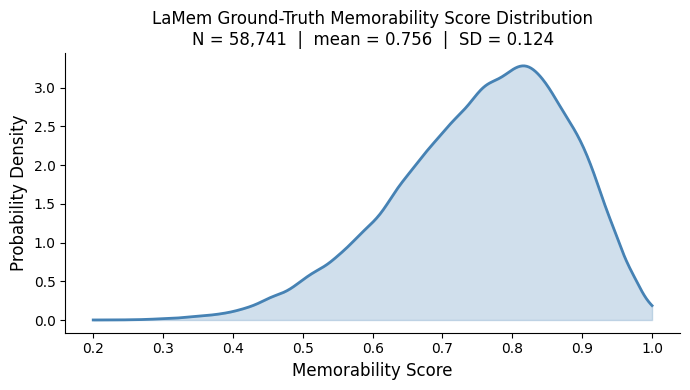

In [ ]:
scores = pd.concat([train['score'], val['score'], test['score']], ignore_index=True).dropna()

kde = gaussian_kde(scores, bw_method='scott')
x = np.linspace(scores.min(), scores.max(), 500)
density = kde(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, density, color='steelblue', linewidth=2)
ax.fill_between(x, density, alpha=0.25, color='steelblue')
ax.set_xlabel('Memorability Score', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(
    f'LaMem Ground-Truth Memorability Score Distribution\n'
    f'N = {len(scores):,}  |  mean = {scores.mean():.3f}  |  SD = {scores.std():.3f}',
    fontsize=12
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
all_lamem = pd.concat([train, val, test], ignore_index=True)
all_lamem.to_csv("../Data/lamem/all_lamem.csv", index=False)
print(f"Saved {len(all_lamem)} rows to ../Data/lamem/all_lamem.csv")

Saved 58741 rows to ../Data/lamem/all_lamem.csv


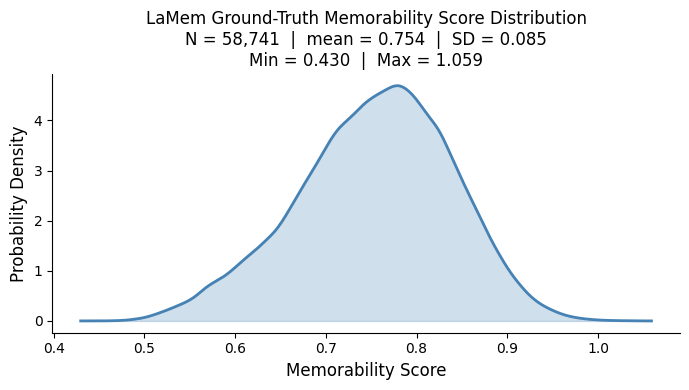

In [ ]:
lamem_pred_fold5 = pd.read_csv("../preds/inference/lamem_20260318_142157/lamem_all_lamem_predictions.csv")
lamem_pred_score_fold5 = lamem_pred_fold5['pred_score']

kde = gaussian_kde(lamem_pred_score_fold5, bw_method='scott')
x = np.linspace(lamem_pred_score_fold5.min(), lamem_pred_score_fold5.max(), 500)
density = kde(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, density, color='steelblue', linewidth=2)
ax.fill_between(x, density, alpha=0.25, color='steelblue')
ax.set_xlabel('Memorability Score', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(
    f'LaMem Ground-Truth Memorability Score Distribution\n'
    f'N = {len(lamem_pred_score_fold5):,}  |  mean = {lamem_pred_score_fold5.mean():.3f}  |  SD = {lamem_pred_score_fold5.std():.3f}\n'
    f'Min = {lamem_pred_score_fold5.min():.3f}  |  Max = {lamem_pred_score_fold5.max():.3f}',
    fontsize=12
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

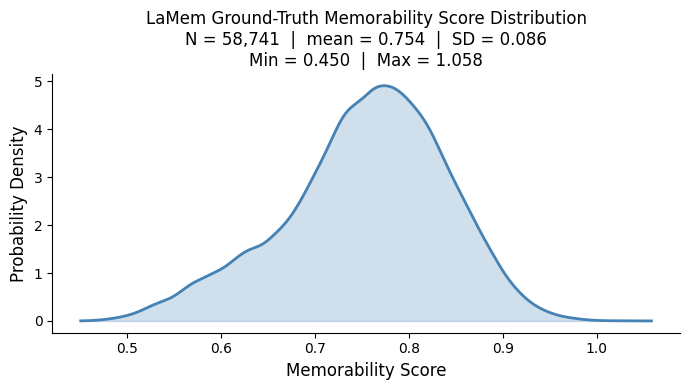

In [ ]:
lamem_pred_fold4 = pd.read_csv("../preds/inference/lamem_20260318_144733/lamem_all_lamem_predictions.csv")
lamem_pred_score_fold4 = lamem_pred_fold4['pred_score']

kde = gaussian_kde(lamem_pred_score_fold4, bw_method='scott')
x = np.linspace(lamem_pred_score_fold4.min(), lamem_pred_score_fold4.max(), 500)
density = kde(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, density, color='steelblue', linewidth=2)
ax.fill_between(x, density, alpha=0.25, color='steelblue')
ax.set_xlabel('Memorability Score', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(
    f'LaMem Ground-Truth Memorability Score Distribution\n'
    f'N = {len(lamem_pred_score_fold4):,}  |  mean = {lamem_pred_score_fold4.mean():.3f}  |  SD = {lamem_pred_score_fold4.std():.3f}\n'
    f'Min = {lamem_pred_score_fold4.min():.3f}  |  Max = {lamem_pred_score_fold4.max():.3f}',
    fontsize=12
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Overlay the plots.

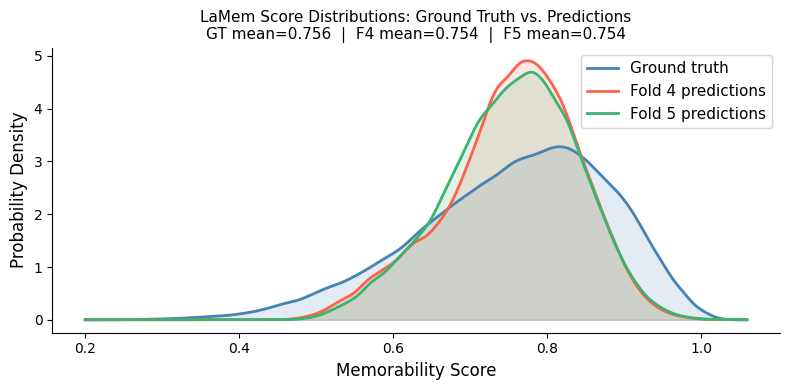

In [ ]:
# Build KDEs
x_min = min(scores.min(), lamem_pred_score_fold4.min(), lamem_pred_score_fold5.min())
x_max = max(scores.max(), lamem_pred_score_fold4.max(), lamem_pred_score_fold5.max())
x = np.linspace(x_min, x_max, 500)

kde_gt   = gaussian_kde(scores,                bw_method='scott')
kde_f4   = gaussian_kde(lamem_pred_score_fold4, bw_method='scott')
kde_f5   = gaussian_kde(lamem_pred_score_fold5, bw_method='scott')

fig, ax = plt.subplots(figsize=(8, 4))

# Ground truth
ax.plot(x, kde_gt(x), color='steelblue', linewidth=2, label='Ground truth')
ax.fill_between(x, kde_gt(x), alpha=0.15, color='steelblue')

# Fold 4
ax.plot(x, kde_f4(x), color='tomato', linewidth=2, label='Fold 4 predictions')
ax.fill_between(x, kde_f4(x), alpha=0.15, color='tomato')

# Fold 5
ax.plot(x, kde_f5(x), color='mediumseagreen', linewidth=2, label='Fold 5 predictions')
ax.fill_between(x, kde_f5(x), alpha=0.15, color='mediumseagreen')

ax.set_xlabel('Memorability Score', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(
    f'LaMem Score Distributions: Ground Truth vs. Predictions\n'
    f'GT mean={scores.mean():.3f}  |  '
    f'F4 mean={lamem_pred_score_fold4.mean():.3f}  |  '
    f'F5 mean={lamem_pred_score_fold5.mean():.3f}',
    fontsize=11
)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Review winning hyperparameters.

In [ ]:
import pandas as pd
vanilla_clip_df = pd.read_csv("../sweep_out/20260318_174237/sweep_results.csv")
best_mse = vanilla_clip_df.loc[vanilla_clip_df["mean_val_mse"].idxmin()]
print(best_mse)

trial_id                44
hidden_dims     (512, 256)
dropout_rate      0.625732
lr                0.000081
weight_decay        0.0205
batch_size             256
mean_val_mse       0.00769
std_val_mse       0.000139
mean_val_rho      0.706284
std_val_rho        0.00941
Name: 42, dtype: object


In [ ]:
import pandas as pd
vanilla_clip_df = pd.read_csv("../sweep_out/20260318_174237/sweep_results.csv")
best_rho = vanilla_clip_df.loc[vanilla_clip_df["mean_val_rho"].idxmax()]
print(best_rho)

trial_id                11
hidden_dims     (512, 256)
dropout_rate       0.69069
lr                0.000121
weight_decay        0.0335
batch_size             256
mean_val_mse       0.00772
std_val_mse       0.000145
mean_val_rho       0.70761
std_val_rho       0.009674
Name: 11, dtype: object


In [ ]:
import pandas as pd
vanilla_clip_df = pd.read_csv("../sweep_out/20260318_174237/sweep_results.csv")
top5_rho = vanilla_clip_df.nlargest(5, "mean_val_rho")
print(top5_rho)

    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
11        11  (512, 256)      0.690690  0.000121        0.0335         256   
22        24  (512, 256)      0.698421  0.000174        0.0726         256   
25        27  (512, 256)      0.635350  0.000059        0.0291         256   
33        35  (512, 256)      0.664971  0.000332        0.0517         256   
32        34  (512, 256)      0.661907  0.000181        0.0549         256   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
11      0.007720     0.000145      0.707610     0.009674  
22      0.007724     0.000128      0.707202     0.008871  
25      0.007695     0.000126      0.706650     0.008992  
33      0.007744     0.000136      0.706578     0.008428  
32      0.007718     0.000139      0.706354     0.009622  


In [ ]:
import pandas as pd
vanilla_clip_df = pd.read_csv("../sweep_out/20260318_174237/sweep_results.csv")
top5_mse = vanilla_clip_df.nsmallest(5, "mean_val_mse")
print(top5_mse)

    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
42        44  (512, 256)      0.625732  0.000081        0.0205         256   
25        27  (512, 256)      0.635350  0.000059        0.0291         256   
41        43  (512, 256)      0.617811  0.000095        0.0221         256   
10        10  (512, 256)      0.649265  0.000152        0.0303         256   
32        34  (512, 256)      0.661907  0.000181        0.0549         256   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
42      0.007690     0.000139      0.706284     0.009410  
25      0.007695     0.000126      0.706650     0.008992  
41      0.007713     0.000145      0.705598     0.009898  
10      0.007716     0.000146      0.706224     0.008667  
32      0.007718     0.000139      0.706354     0.009622  


In [ ]:
import pandas as pd
clip_hba_df = pd.read_csv("../sweep_out/20260318_100446/sweep_results.csv")
best_rho = clip_hba_df.loc[clip_hba_df["mean_val_rho"].idxmax()]
print(best_rho)

trial_id                16
hidden_dims     (256, 128)
dropout_rate      0.653257
lr                0.000017
weight_decay       0.00495
batch_size              64
mean_val_mse      0.007607
std_val_mse       0.000211
mean_val_rho      0.712804
std_val_rho       0.011062
Name: 16, dtype: object


In [ ]:
import pandas as pd
clip_hba_df = pd.read_csv("../sweep_out/20260318_100446/sweep_results.csv")
best_mse = clip_hba_df.loc[clip_hba_df["mean_val_mse"].idxmin()]
print(best_mse)

trial_id                38
hidden_dims     (512, 256)
dropout_rate      0.585585
lr                0.000038
weight_decay      0.000536
batch_size             128
mean_val_mse      0.007569
std_val_mse       0.000162
mean_val_rho      0.710192
std_val_rho       0.008828
Name: 37, dtype: object


In [ ]:
clip_hba_df = pd.read_csv("../sweep_out/20260318_100446/sweep_results.csv")
top5_rho = clip_hba_df.nlargest(5, "mean_val_rho")
print(top5_rho)

    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
16        16  (256, 128)      0.653257  0.000017       0.00495          64   
39        40  (512, 256)      0.685898  0.000041       0.00203         128   
44        45  (512, 256)      0.691643  0.000060       0.00312         128   
48        49  (512, 256)      0.669480  0.000059       0.00410         128   
40        41  (512, 256)      0.627116  0.000067       0.00704         128   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
16      0.007607     0.000211      0.712804     0.011062  
39      0.007586     0.000205      0.712114     0.008321  
44      0.007594     0.000197      0.712085     0.008366  
48      0.007587     0.000189      0.711334     0.009397  
40      0.007576     0.000171      0.711071     0.009367  


In [ ]:
clip_hba_df = pd.read_csv("../sweep_out/20260318_100446/sweep_results.csv")
top5_mse = clip_hba_df.nsmallest(5, "mean_val_mse")
print(top5_mse)

    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
37        38  (512, 256)      0.585585  0.000038      0.000536         128   
38        39  (512, 256)      0.597060  0.000038      0.001710         128   
40        41  (512, 256)      0.627116  0.000067      0.007040         128   
13        13  (256, 128)      0.443975  0.000018      0.019500         256   
41        42  (512, 256)      0.626966  0.000064      0.005640         128   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
37      0.007569     0.000162      0.710192     0.008828  
38      0.007569     0.000160      0.710511     0.008480  
40      0.007576     0.000171      0.711071     0.009367  
13      0.007578     0.000198      0.710070     0.011421  
41      0.007581     0.000180      0.710979     0.009319  


In [ ]:
clip_hba_df = pd.read_csv("../sweep_out/20260318_100446/sweep_results.csv")
bottom5_rho = clip_hba_df.nsmallest(5, "mean_val_rho")
print(bottom5_rho)

    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
30        31  (512, 256)      0.110415  0.000147      0.002550         128   
2          2      (256,)      0.219804  0.000075      0.002340          64   
3          3  (256, 128)      0.158603  0.000145      0.000576         256   
5          5  (512, 256)      0.295198  0.000046      0.000122          32   
1          1  (512, 256)      0.210043  0.000033      0.001260         128   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
30      0.008067     0.000155      0.686678     0.010656  
2       0.007913     0.000224      0.694131     0.009667  
3       0.007848     0.000205      0.696975     0.010969  
5       0.007812     0.000226      0.698251     0.011323  
1       0.007794     0.000188      0.698736     0.009390  


In [ ]:
clip_hba_df = pd.read_csv("../sweep_out/20260318_100446/sweep_results.csv")
bottom5_mse = clip_hba_df.nlargest(5, "mean_val_mse")
print(bottom5_mse)

    trial_id      hidden_dims  dropout_rate        lr  weight_decay  \
30        31       (512, 256)      0.110415  0.000147      0.002550   
2          2           (256,)      0.219804  0.000075      0.002340   
14        14  (512, 256, 128)      0.465986  0.000022      0.014400   
12        12       (256, 128)      0.667486  0.000011      0.092900   
3          3       (256, 128)      0.158603  0.000145      0.000576   

    batch_size  mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
30         128      0.008067     0.000155      0.686678     0.010656  
2           64      0.007913     0.000224      0.694131     0.009667  
14          64      0.007913     0.000193      0.703926     0.011975  
12         256      0.007850     0.000231      0.707017     0.009057  
3          256      0.007848     0.000205      0.696975     0.010969  


CLIP-HBA-Mem combined LaMem + MemCat hyperparameter sweep results

In [11]:
import pandas as pd
from pathlib import Path
from typing import NamedTuple

clip_hba_combined_lamem_memcat = pd.read_csv("../sweep_out/20260323_092320/sweep_results.csv")
#print(clip_hba_combined_lamem_memcat)
top5_rho = clip_hba_combined_lamem_memcat.nlargest(5, "mean_val_rho")
top5_mse = clip_hba_combined_lamem_memcat.nsmallest(5, "mean_val_mse")
print(top5_mse)
print(top5_rho)

    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
4          4  (256, 128)      0.428026  0.000021      0.075600          64   
13        14  (256, 128)      0.435311  0.000018      0.017900          64   
45        46  (256, 128)      0.408602  0.000013      0.000011          32   
31        32  (256, 128)      0.422730  0.000015      0.000391          32   
43        44  (256, 128)      0.436081  0.000022      0.000029          32   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
4       0.005655     0.000085      0.764514     0.002198  
13      0.005663     0.000085      0.764498     0.002122  
45      0.005669     0.000081      0.763797     0.002047  
31      0.005670     0.000083      0.763553     0.002020  
43      0.005671     0.000085      0.764132     0.002260  
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
30        31  (256, 128)      0.616354  0.000018      0.000151          32   
17        18  (256, 1

In [12]:
vanilla_clip_combined_lamem_memcat = pd.read_csv("../sweep_out/clip_frozen_mlp_20260323_092652/sweep_results.csv")
#print(clip_hba_combined_lamem_memcat)
top5_rho = vanilla_clip_combined_lamem_memcat.nlargest(5, "mean_val_rho")
top5_mse = vanilla_clip_combined_lamem_memcat.nsmallest(5, "mean_val_mse")
print(top5_mse)
print(top5_rho)

    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
47        48  (512, 256)      0.536829  0.000012        0.0706          32   
45        46  (256, 128)      0.530101  0.000012        0.0629          32   
49        50  (512, 256)      0.540400  0.000012        0.0490          32   
44        45  (256, 128)      0.533272  0.000012        0.0520          32   
42        43  (256, 128)      0.493260  0.000012        0.0348          32   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
47      0.005846     0.000087      0.756576     0.003524  
45      0.005849     0.000093      0.757171     0.003159  
49      0.005850     0.000088      0.756539     0.003620  
44      0.005852     0.000093      0.757257     0.003165  
42      0.005856     0.000096      0.756472     0.003220  
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
11        11  (512, 256)      0.682552  0.000115      0.085300          64   
13        13  (512, 2

In [2]:
from pathlib import Path
from typing import NamedTuple


class MegSweepResults(NamedTuple):
    """Parsed from a path segment like ``.../tp600/sweep_results.csv``."""

    time_point: str
    df: pd.DataFrame
    top5_rho: pd.DataFrame
    top5_mse: pd.DataFrame


_TP_DIR = re.compile(r"[/\\](tp-?\d+)[/\\]", re.IGNORECASE)


def load_meg_sweep_results(
    sweep_results_csv: str | Path,
    top_n: int = 5,
) -> MegSweepResults:
    """Load ``sweep_results.csv``; time point is taken from a ``tp*`` parent folder name."""
    path = Path(sweep_results_csv)
    m = _TP_DIR.search(str(path))
    if m is None:
        raise ValueError(
            f"Could not parse time point (expected a .../tp<ms>/... path segment): {path}"
        )
    time_point = m.group(1)
    df = pd.read_csv(path)
    top5_rho = df.nlargest(top_n, "mean_val_rho")
    top5_mse = df.nsmallest(top_n, "mean_val_mse")
    return MegSweepResults(time_point, df, top5_rho, top5_mse)


50ms

In [16]:
meg_tp50 = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260401_094506/tp50/sweep_results.csv")
print(meg_tp50.time_point, meg_tp50.top5_mse, sep="\n")
print(meg_tp50.time_point, meg_tp50.top5_rho, sep="\n")

tp50
    trial_id     hidden_dims  dropout_rate        lr  weight_decay  \
16        18  (256, 128, 32)      0.302054  0.000161      0.000144   
46        48  (256, 128, 32)      0.387428  0.000140      0.000036   
31        33  (256, 128, 32)      0.356612  0.000057      0.000214   
24        26  (256, 128, 32)      0.453722  0.000161      0.000023   
42        44  (256, 128, 32)      0.360054  0.000058      0.000091   

    batch_size  mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
16          32      0.009791     0.000101      0.527600     0.004304  
46          32      0.009791     0.000108      0.528055     0.004152  
31          32      0.009792     0.000094      0.528105     0.003694  
24          32      0.009795     0.000107      0.528628     0.004392  
42          32      0.009795     0.000094      0.527700     0.003433  
tp50
    trial_id     hidden_dims  dropout_rate        lr  weight_decay  \
29        31  (256, 128, 32)      0.540635  0.000098      0.000041   
24 

100ms

In [12]:
meg_tp100 = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260331_140842/tp100/sweep_results.csv")
print(meg_tp100.time_point, meg_tp100.top5_mse, sep="\n")
print(meg_tp100.time_point, meg_tp100.top5_rho, sep="\n")

tp100
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
12        12   (256, 64)      0.350406  0.000275        0.0914          64   
41        41   (256, 64)      0.322068  0.000293        0.0253         128   
33        33   (256, 64)      0.296400  0.000261        0.0362          64   
34        34   (256, 64)      0.304783  0.000193        0.0377          64   
39        39   (256, 64)      0.308746  0.000269        0.0216         128   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
12      0.008413     0.000144      0.616917     0.007070  
41      0.008427     0.000144      0.617194     0.006166  
33      0.008429     0.000140      0.615416     0.005371  
34      0.008430     0.000132      0.616051     0.006556  
39      0.008436     0.000137      0.616208     0.006417  
tp100
    trial_id     hidden_dims  dropout_rate        lr  weight_decay  \
36        36       (256, 64)      0.396172  0.000152       0.01740   
11        11       (256, 

150ms

In [17]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260401_094526/tp150/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp150
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
16        17   (256, 64)      0.352754  0.000141      0.096100          32   
45        46   (256, 64)      0.392771  0.000166      0.000272         256   
23        24   (256, 64)      0.441103  0.000159      0.099200          32   
47        48   (256, 64)      0.269313  0.000169      0.000318         128   
41        42   (256, 64)      0.393207  0.000198      0.000597         256   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
16      0.008154     0.000051      0.631050     0.001796  
45      0.008156     0.000069      0.631608     0.002029  
23      0.008160     0.000069      0.632468     0.002424  
47      0.008161     0.000075      0.630743     0.002784  
41      0.008164     0.000067      0.631164     0.002022  
tp150
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
23        24   (256, 64)      0.441103  0.000159      0.099200          32   
33       

200ms

In [11]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260331_092603/tp200/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp200
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
46        46   (256, 64)      0.346478  0.000120        0.0401         256   
43        43   (256, 64)      0.432955  0.000093        0.0537          64   
33        33   (256, 64)      0.405242  0.000129        0.0234          64   
48        48   (256, 64)      0.296311  0.000117        0.0402         256   
42        42   (256, 64)      0.419016  0.000096        0.0508          64   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
46      0.007817     0.000066      0.648866     0.002696  
43      0.007821     0.000063      0.650004     0.002460  
33      0.007822     0.000071      0.648996     0.002776  
48      0.007826     0.000068      0.647677     0.003009  
42      0.007828     0.000064      0.649486     0.002508  
tp200
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
44        44   (256, 64)      0.426246  0.000089        0.0561          64   
43       

250ms

In [19]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260401_094639/tp250/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp250
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
31        32   (256, 64)      0.440978  0.000090      0.005670         128   
26        27   (256, 64)      0.342443  0.000071      0.003090         128   
42        43   (256, 64)      0.390005  0.000100      0.000689         128   
41        42   (256, 64)      0.439395  0.000099      0.001670         128   
45        46   (256, 64)      0.393008  0.000104      0.000252         128   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
31      0.007698     0.000083      0.657435     0.003949  
26      0.007705     0.000081      0.656164     0.003056  
42      0.007706     0.000074      0.656508     0.003198  
41      0.007707     0.000090      0.657336     0.003486  
45      0.007708     0.000070      0.656608     0.002711  
tp250
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
31        32   (256, 64)      0.440978  0.000090      0.005670         128   
41       

300ms

In [10]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260331_143706/tp300/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp300
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
32        32   (256, 64)      0.393440  0.000092        0.0164          32   
41        41   (256, 64)      0.472060  0.000090        0.0199          32   
26        26   (256, 64)      0.342443  0.000092        0.0203          32   
34        34   (256, 64)      0.495019  0.000089        0.0490          32   
43        43   (256, 64)      0.454898  0.000085        0.0104          32   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
32      0.007566     0.000081      0.664908     0.002553  
41      0.007566     0.000100      0.664749     0.003558  
26      0.007569     0.000073      0.663750     0.002547  
34      0.007569     0.000075      0.665388     0.002337  
43      0.007572     0.000087      0.664410     0.003097  
tp300
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
34        34   (256, 64)      0.495019  0.000089        0.0490          32   
32       

350ms

In [20]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260401_094648/tp350/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp350
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
12        14   (256, 64)      0.327360  0.000227      0.001500          64   
14        16   (256, 64)      0.453149  0.000219      0.001380          64   
31        34   (256, 64)      0.290022  0.000238      0.000197          64   
22        24   (256, 64)      0.220523  0.000219      0.000186          64   
11        13   (256, 64)      0.273970  0.000222      0.000271          64   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
12      0.007310     0.000090      0.678211     0.002353  
14      0.007310     0.000083      0.679857     0.001536  
31      0.007312     0.000080      0.678705     0.002053  
22      0.007314     0.000078      0.678181     0.002540  
11      0.007317     0.000067      0.678212     0.002570  
tp350
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
33        36   (256, 64)      0.502563  0.000101      0.000027          64   
14       

400ms

In [9]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260331_094644/tp400/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp400
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
46        46   (256, 64)      0.291867  0.000109       0.02740         128   
48        48   (256, 64)      0.334586  0.000148       0.00956         128   
44        44   (256, 64)      0.279124  0.000100       0.05980         128   
42        42   (256, 64)      0.266209  0.000095       0.02270         128   
23        23   (256, 64)      0.319702  0.000064       0.00543         128   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
46      0.007250     0.000074      0.681834     0.002780  
48      0.007252     0.000078      0.681747     0.002185  
44      0.007258     0.000077      0.681244     0.002662  
42      0.007261     0.000080      0.681014     0.002325  
23      0.007264     0.000082      0.681832     0.003156  
tp400
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
26        26   (256, 64)      0.514698  0.000092       0.00159          32   
32       

500ms

In [21]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260401_175700/tp500/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp500
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
46        48   (256, 64)      0.327694  0.000103       0.03620          64   
31        33   (256, 64)      0.374450  0.000082       0.08800         256   
32        34   (256, 64)      0.328194  0.000081       0.01580         256   
34        36   (256, 64)      0.383042  0.000088       0.01530         256   
15        17   (256, 64)      0.349267  0.000070       0.00998          64   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
46      0.007220     0.000075      0.683319     0.002717  
31      0.007221     0.000076      0.683619     0.002413  
32      0.007222     0.000086      0.683174     0.002305  
34      0.007227     0.000080      0.683734     0.001929  
15      0.007228     0.000076      0.683860     0.002443  
tp500
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
21        23   (256, 64)      0.402780  0.000077       0.06340         256   
15       

600ms

In [8]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260331_010925/tp600/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp600
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
27        27   (256, 64)      0.303617  0.000143        0.0321          64   
33        33   (256, 64)      0.273812  0.000140        0.0211          64   
44        44   (256, 64)      0.303378  0.000205        0.0297          64   
34        34   (256, 64)      0.285859  0.000139        0.0173          64   
41        41   (256, 64)      0.274249  0.000133        0.0234          64   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
27      0.007139     0.000067      0.687024     0.001852  
33      0.007141     0.000063      0.686212     0.002064  
44      0.007143     0.000063      0.686545     0.001390  
34      0.007144     0.000062      0.687119     0.001596  
41      0.007146     0.000067      0.686794     0.001899  
tp600
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
34        34   (256, 64)      0.285859  0.000139        0.0173          64   
42       

700ms

In [22]:
meg = load_meg_sweep_results("C:/Users/BrainInspired/Documents/GitHub/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260402_133401/tp700/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp700
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
15        15   (256, 64)      0.413834  0.000335        0.0820          64   
43        43   (256, 64)      0.409009  0.000282        0.0618          64   
47        47   (256, 64)      0.498294  0.000278        0.0714          64   
23        23   (256, 64)      0.438973  0.000221        0.0514          64   
32        32   (256, 64)      0.363932  0.000249        0.0135          64   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
15      0.007098     0.000079      0.689751     0.002203  
43      0.007100     0.000058      0.689938     0.001566  
47      0.007105     0.000072      0.689782     0.002338  
23      0.007112     0.000069      0.690038     0.002650  
32      0.007114     0.000067      0.689423     0.001698  
tp700
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
23        23   (256, 64)      0.438973  0.000221        0.0514          64   
43       

800ms

In [23]:
meg = load_meg_sweep_results("C:/Users/BrainInspired/Documents/GitHub/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260402_133543/tp800/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp800
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
32        32   (256, 64)      0.444876  0.000175        0.0479          32   
30        30   (256, 64)      0.458227  0.000178        0.0524          32   
36        36   (256, 64)      0.595449  0.000111        0.0723          32   
31        31   (256, 64)      0.449558  0.000179        0.0445          32   
37        37   (256, 64)      0.613395  0.000123        0.0686          32   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
32      0.007105     0.000079      0.689049     0.002132  
30      0.007106     0.000060      0.690145     0.001218  
36      0.007109     0.000049      0.690692     0.002154  
31      0.007116     0.000074      0.689364     0.001964  
37      0.007120     0.000075      0.689903     0.002305  
tp800
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
36        36   (256, 64)      0.595449  0.000111        0.0723          32   
42       

900ms

In [24]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260331_093940/tp900/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp900
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
44        44   (256, 64)      0.452401  0.000175        0.0626          32   
43        43   (256, 64)      0.426365  0.000181        0.0540          32   
32        32   (256, 64)      0.216264  0.000153        0.0643          32   
48        48   (256, 64)      0.565841  0.000124        0.0635          64   
33        33   (256, 64)      0.224232  0.000140        0.0529          32   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
44      0.007059     0.000054      0.694244     0.001193  
43      0.007068     0.000064      0.693296     0.000818  
32      0.007112     0.000058      0.690866     0.002687  
48      0.007112     0.000066      0.692548     0.002026  
33      0.007116     0.000045      0.690429     0.001644  
tp900
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
44        44   (256, 64)      0.452401  0.000175        0.0626          32   
43       

1000ms

In [25]:
meg = load_meg_sweep_results("C:/Users/BrainInspired/Documents/GitHub/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260402_133317/tp1000/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")


tp1000
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
32        32   (256, 64)      0.463808  0.000141      0.001280          32   
33        33   (256, 64)      0.495639  0.000157      0.000415          32   
27        27   (256, 64)      0.519322  0.000177      0.002360          32   
34        34   (256, 64)      0.469367  0.000136      0.000375          32   
44        44   (256, 64)      0.541600  0.000240      0.001130          32   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
32      0.007105     0.000062      0.691544     0.002565  
33      0.007113     0.000050      0.691363     0.001884  
27      0.007120     0.000051      0.692357     0.003126  
34      0.007121     0.000060      0.691750     0.001940  
44      0.007125     0.000050      0.691223     0.001880  
tp1000
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
27        27   (256, 64)      0.519322  0.000177      0.002360          32   
34     

1100ms

In [27]:
meg = load_meg_sweep_results("C:/Users/BrainInspired/Documents/GitHub/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260402_133341/tp1100/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp1100
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
30        30   (256, 64)      0.458227  0.000178        0.0427          32   
31        31   (256, 64)      0.449558  0.000180        0.0502          32   
41        41   (256, 64)      0.449421  0.000142        0.0402          32   
42        42   (256, 64)      0.485134  0.000148        0.0299          32   
33        33   (256, 64)      0.481775  0.000167        0.0181          32   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
30      0.007382     0.000090      0.671524     0.002990  
31      0.007383     0.000070      0.671673     0.001991  
41      0.007388     0.000071      0.671750     0.002101  
42      0.007392     0.000086      0.671733     0.002774  
33      0.007397     0.000075      0.670453     0.001963  
tp1100
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
41        41   (256, 64)      0.449421  0.000142        0.0402          32   
42     

1200ms

In [28]:
meg = load_meg_sweep_results("C:/Users/BrainInspired/Documents/GitHub/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260402_133410/tp1200/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp1200
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
42        42   (256, 64)      0.462034  0.000283        0.0616          64   
43        43   (256, 64)      0.459460  0.000270        0.0573          64   
33        33   (256, 64)      0.420153  0.000208        0.0853          64   
27        27   (256, 64)      0.490705  0.000161        0.0556          64   
23        23   (256, 64)      0.467485  0.000166        0.0514          64   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
42      0.007419     0.000109      0.669617     0.004602  
43      0.007422     0.000107      0.668832     0.004188  
33      0.007426     0.000097      0.668149     0.004551  
27      0.007433     0.000108      0.669008     0.004254  
23      0.007438     0.000091      0.668522     0.004630  
tp1200
    trial_id hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
42        42   (256, 64)      0.462034  0.000283        0.0616          64   
27     

1300ms

In [7]:
meg = load_meg_sweep_results("Z:/multimodal_brain_inspired/marren/CLIP-HBA-Mem/CLIP-HBA/sweep_meg_out/20260331_011128/tp1300/sweep_results.csv")
print(meg.time_point, meg.top5_mse, sep="\n")
print(meg.time_point, meg.top5_rho, sep="\n")

tp1300
    trial_id    hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
32        35  (128, 64, 16)      0.151573  0.000419        0.0952         256   
33        36  (128, 64, 16)      0.142386  0.000414        0.0853         256   
41        44  (128, 64, 16)      0.147461  0.000284        0.0947         256   
44        47  (128, 64, 16)      0.101693  0.000385        0.0944         128   
28        31  (128, 64, 16)      0.321847  0.000493        0.0865         256   

    mean_val_mse  std_val_mse  mean_val_rho  std_val_rho  
32      0.007885     0.000080      0.644918     0.003916  
33      0.007887     0.000071      0.644263     0.003766  
41      0.007893     0.000080      0.643878     0.004235  
44      0.007896     0.000076      0.643344     0.002656  
28      0.007900     0.000080      0.645245     0.002336  
tp1300
    trial_id    hidden_dims  dropout_rate        lr  weight_decay  batch_size  \
28        31  (128, 64, 16)      0.321847  0.000493        0.086

MEGMem Final Model

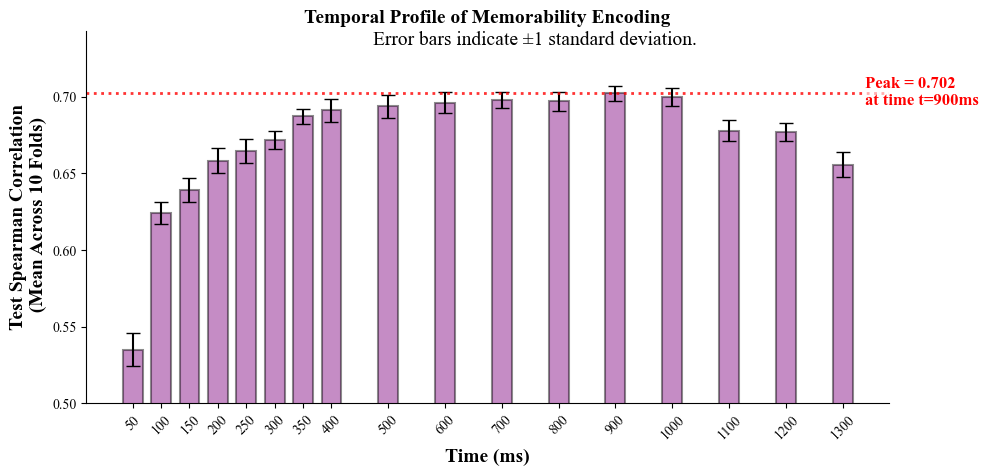

In [37]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set Times New Roman as the default font for all text in the plot
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# The above also ensures tick labels/fonts are set.

megmem_final_res = pd.read_csv("../Data/megmem_final_results.csv")

plt.figure(figsize=(10, 5))
bars = plt.bar(
    megmem_final_res['time'],
    megmem_final_res['mean_test_spearman'],
    yerr=megmem_final_res['sd_test_spearman'],
    capsize=5,
    color="purple",
    edgecolor="black",
    width=35  # Make the bars wider
)

# Set transparency for the *fill* only, and keep the edges opaque
for bar in bars:
    bar.set_alpha(.45)
    bar.set_linewidth(1.5)
    bar.set_edgecolor("black")
    bar.set_facecolor((0.5, 0, 0.5, 0.4))  # (R,G,B,alpha=0.4) for purple fill

plt.xlabel("Time (ms)", fontweight='bold', fontname='Times New Roman', fontsize=14)
plt.ylabel("Test Spearman Correlation\n (Mean Across 10 Folds)", fontweight='bold', fontname='Times New Roman', fontsize=14)

# Make the title bold by setting fontweight='bold'
plt.title("Temporal Profile of Memorability Encoding", fontweight='bold', fontname='Times New Roman', fontsize=14)
plt.ylim(0.5, None)  # Set y-axis to start at 0.5

# Set the x-tick labels to be the time values, one label per bar
plt.xticks(megmem_final_res['time'], megmem_final_res['time'], rotation=45, fontname='Times New Roman')

# Remove top and right borders (spines)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add a note about the meaning of error bars
plt.figtext(0.54, 0.9, "Error bars indicate ±1 standard deviation.", ha='center', fontsize=14, fontname='Times New Roman')

# Add a dotted horizontal line at the peak Spearman correlation
peak_spearman = megmem_final_res['mean_test_spearman'].max()
plt.axhline(peak_spearman, color='red', linestyle=':', linewidth=2, alpha=0.8)
plt.text(
    megmem_final_res['time'].iloc[-1] + 40,  # right of last bar
    peak_spearman,
    f'Peak = {peak_spearman:.3f}\nat time t=900ms', 
    va='center',
    ha='left',
    color='red',
    fontsize=12,
    fontname='Times New Roman',
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
)

plt.tight_layout(rect=[0, 0.03, 1, 1])  # Make room for note below
plt.show()

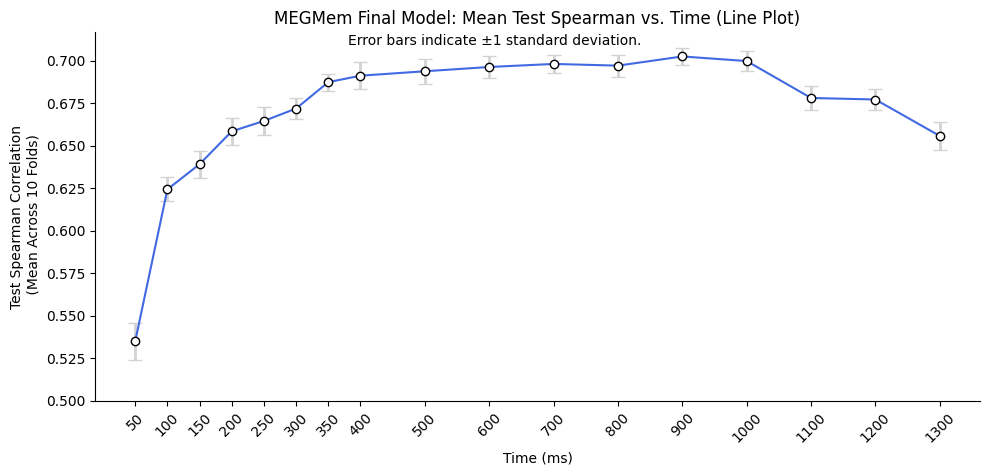

In [12]:
plt.figure(figsize=(10, 5))
plt.errorbar(
    megmem_final_res['time'],
    megmem_final_res['mean_test_spearman'],
    yerr=megmem_final_res['sd_test_spearman'],
    fmt='-o',
    color="royalblue",
    ecolor="lightgray",
    elinewidth=2,
    capsize=5,
    markerfacecolor='white',
    markeredgecolor='black'
)

plt.xlabel("Time (ms)")
plt.ylabel("Test Spearman Correlation\n (Mean Across 10 Folds)")
plt.title("MEGMem Final Model: Mean Test Spearman vs. Time (Line Plot)")
plt.ylim(0.5, None)

plt.xticks(megmem_final_res['time'], rotation=45)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.figtext(0.5, 0.9, "Error bars indicate ±1 standard deviation.", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()